# Generating new faces with Variational Autoencoders (VAE)
This script demonstrates the process of building and training a VAE using Keras to generate new faces. We shall be using the CelebFaces Attributes (CelebA) Dataset from Kaggle for training the VAE model. Some parts of the Markdown notes are extracted from [Understanding Variational Autoencoders (VAEs)](https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73) 

## Simple Autoencoder
I first built a simple Autoencoder. A simple Autoencoder consists of two neural networks - an Encoder and a Decoder. An Encoder is responsible for converting an image into a compact lower dimensional vector (or latent vector). This latent vector is a compressed representation of the image. The Encoder maps an input from the higher dimensional input space to the lower dimensional latent space, a concept that is similar to a CNN classifier. The outputs of the encoder are then fed into the Decoder. The Decoder is a different neural network that tries to reconstruct the image from the lower dimensional latent space to the higher dimensional output space. The Encoder and Decoder perform mappings that are exactly opposite to each other, as shown in the image.

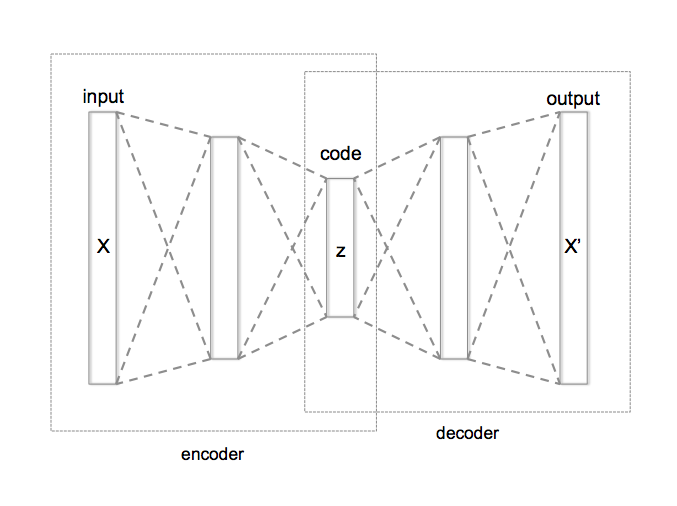

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Conv2DTranspose, Reshape, Lambda, Activation, LeakyReLU
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
from glob import glob

2026-03-27 15:41:54.906946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774626114.930311     209 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774626114.937883     209 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774626114.956333     209 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774626114.956358     209 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774626114.956361     209 computation_placer.cc:177] computation placer alr

## Data preparation

I am not using Kera's flow_from_directory method because the function seems to hang on Kaggle. I took reference from Github the function of build_decoder to prepare the dataset for training. 

In [2]:
WEIGHTS_FOLDER = '/kaggle/working/weights/'
DATA_FOLDER = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/'
Z_DIM = 200

if not os.path.exists(WEIGHTS_FOLDER):
  os.makedirs(os.path.join(WEIGHTS_FOLDER,"AE"))
  os.makedirs(os.path.join(WEIGHTS_FOLDER,"VAE"))

filenames = np.array(glob(os.path.join(DATA_FOLDER, '*.jpg')))
NUM_IMAGES = len(filenames)
print("Total number of images : " + str(NUM_IMAGES))

Total number of images : 202599


In [3]:
def build_decoder(test=False, out_size=(128, 128)):
    def decoder(path):
        img = file_bytes = tf.io.read_file(path)
        img = tf.image.decode_jpeg(file_bytes, channels=3)  
        img = tf.image.resize(img, (128, 128))
        img = tf.cast(img, tf.float32) / 255.0
        return img
    def decoder_train(path):
        return decoder(path), decoder(path)

    return decoder if test else decoder_train

def build_dataset(paths, test=False, shuffle=1, batch_size=1):
    AUTO = tf.data.experimental.AUTOTUNE
    decoder = build_decoder(test)

    dset = tf.data.Dataset.from_tensor_slices(paths)
    dset = dset.map(decoder, num_parallel_calls=AUTO)
    
    dset = dset.shuffle(shuffle)
    dset = dset.batch(batch_size)
    return dset

In [4]:
train_paths, valid_paths, _, _ = train_test_split(filenames, filenames, test_size=0.2, shuffle=True)

train_dataset = build_dataset(train_paths, batch_size=128)
valid_dataset = build_dataset(valid_paths, batch_size=128)

I0000 00:00:1774626127.050836     209 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
LEARNING_RATE = 0.0005
N_EPOCHS = 20

optimizer = Adam(learning_rate = LEARNING_RATE)

def r_loss(y_true, y_pred):
    return K.mean(K.square(y_true - y_pred), axis = [1,2,3])

## Variable Autoencoder

A variational autoencoder can be defined as being an autoencoder whose training is regularised to avoid overfitting and ensure that the latent space has good properties that enable generative process. A variational autoencoder is an architecture composed of both an encoder and a decoder and is trained to minimise the reconstruction error between the encoded-decoded data and the initial data. In addition, regularisation of the latent space is introduced within the process of encoding-decoding. This is done via a slight modification where instead of encoding an input as a single point, we encode it as a distribution over the latent space. The model is then trained as follows:
1. The input is encoded as distribution over the latent space
2. A point from the latent space is sampled from that distribution
3. The sampled point is decoded and the reconstruction error can be computed
4. The reconstruction error is backpropagated through the network

The loss function used is the sum of RMSE and KL Divergence. A weight is assigned to the RMSE loss, known as the loss factor. The loss factor is multiplied with the RMSE loss. If we use a high loss factor, the drawbacks of a Simple Autoencoder start to appear. However, if we use a loss factor too low, the quality of the reconstructed images will be poor. Hence the loss factor is a hyperparameter that needs to be tuned.

The section covers the definition of the Variable Autoencoder defined within a VariableAutoencoder Class.

In [6]:
import keras
from keras import ops, layers

# 1. Define a custom layer to handle the VAE loss
class VAELossLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        input_encoder, output_vae, latent_mu, latent_log_var = inputs
        
        # Reconstruction Loss
        # Flatten and calculate binary crossentropy
        y_true = ops.reshape(input_encoder, [-1])
        y_pred = ops.reshape(output_vae, [-1])
        rec_loss = keras.losses.binary_crossentropy(y_true, y_pred)
        reconstruction_loss = ops.mean(rec_loss) * (128 * 128 * 3)

        # KL Divergence
        kl_loss = -0.5 * ops.sum(1 + latent_log_var - ops.square(latent_mu) - ops.exp(latent_log_var), axis=-1)
        kl_loss = ops.mean(kl_loss)

        # Add the total loss to the layer
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        
        # Log metrics so they show up during training
        self.add_metric(reconstruction_loss, name='reconstruction_loss')
        self.add_metric(kl_loss, name='kl_divergence_loss')

        return output_vae # The layer just passes the reconstruction through

In [32]:
import numpy as np
import keras
from keras import ops, layers, Model, Input

class VAE(Model):
    def __init__(self, encoder, decoder, z_dim, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.z_dim = z_dim
        # Trackers for metrics
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        # 1. Get the latent representation (we only need the 'z' sample for inference)
        _, _, z = self.encoder(inputs)
        # 2. Reconstruct the image
        return self.decoder(z)
        
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # Keras 3 passes data as a tuple (x, y) if using a generator/dataset,
        # but for VAEs we usually just need x.
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape: # Changed from keras.GradientTape
            # 1. Forward pass through encoder
            z_mean, z_log_var, z = self.encoder(data)
            
            # 2. Forward pass through decoder
            reconstruction = self.decoder(z)
            
            # 3. Compute Reconstruction Loss
            y_true = ops.reshape(data, [-1])
            y_pred = ops.reshape(reconstruction, [-1])
            rec_loss = keras.losses.binary_crossentropy(y_true, y_pred)
            reconstruction_loss = ops.mean(rec_loss) * (128 * 128 * 3)

            # 4. Compute KL Divergence Loss
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        # 5. Backward pass
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # 6. Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    def test_step(self, data):
        # Handle the case where the dataset yields (x, y) tuples
        if isinstance(data, tuple):
            data = data[0]
            
        # 1. Forward pass
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        
        # 2. Compute Reconstruction Loss
        y_true = ops.reshape(data, [-1])
        y_pred = ops.reshape(reconstruction, [-1])
        rec_loss = keras.losses.binary_crossentropy(y_true, y_pred)
        reconstruction_loss = ops.mean(rec_loss) * (128 * 128 * 3)

        # 3. Compute KL Divergence Loss
        kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
        kl_loss = ops.mean(ops.sum(kl_loss, axis=1))

        total_loss = reconstruction_loss + kl_loss

        # 4. Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

class VariableAutoencoder:
    def __init__(self):
        self.input_dim = (128, 128, 3)
        self.z_dim = 200
        self.learning_rate = 0.0005
        self.var_autoencoder_model = None
        self.var_encoder_model = None
        self.var_decoder_model = None
        
    def build(self):
        # --- ENCODER ---
        encoder_input = Input(shape=self.input_dim, name="encoder_input")
        x = layers.Conv2D(32, 3, strides=2, padding="same")(encoder_input)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        
        conv_shape = ops.shape(x)[1:] # Get shape for decoder reshape
        x = layers.Flatten()(x)
        
        latent_mu = layers.Dense(self.z_dim, name="latent_mu")(x)
        latent_log_var = layers.Dense(self.z_dim, name="latent_log_var")(x)

        # Sampling Logic
        def sampling(args):
            z_mean, z_log_var = args
            batch = ops.shape(z_mean)[0]
            dim = ops.shape(z_mean)[1]
            epsilon = keras.random.normal(shape=(batch, dim))
            return z_mean + ops.exp(0.5 * z_log_var) * epsilon

        z = layers.Lambda(sampling, name="z")([latent_mu, latent_log_var])
        self.var_encoder_model = Model(encoder_input, [latent_mu, latent_log_var, z], name="encoder")

        # --- DECODER ---
        latent_input = Input(shape=(self.z_dim,), name="decoder_input")
        x = layers.Dense(np.prod(conv_shape))(latent_input)
        x = layers.Reshape(conv_shape)(x)
        x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
        x = layers.LeakyReLU()(x)
        x = layers.Conv2DTranspose(3, 3, strides=2, padding="same")(x)
        decoder_output = layers.Activation("sigmoid")(x)
        
        self.var_decoder_model = Model(latent_input, decoder_output, name="decoder")

        # --- VAE MODEL ---
        self.var_autoencoder_model = VAE(self.var_encoder_model, self.var_decoder_model, self.z_dim)
        self.var_autoencoder_model.compile(optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate))

    def get_varautoencoder(self): return self.var_autoencoder_model
    def get_varencoder(self): return self.var_encoder_model
    def get_vardecoder(self): return self.var_decoder_model

# Execution
var_model = VariableAutoencoder()
var_model.build()

vae = var_model.get_varautoencoder()
vae.encoder.summary()
vae.decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 64, 64,    │        896 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_112     │ (None, 64, 64,    │          0 │ conv2d_64[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 32, 32,    │     18,496 │ leaky_re_lu_112[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_113     │ (None, 32, 32,    │          0 │ conv2d_65[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 16, 16,    │     36,928 │ leaky_re_lu_113[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_114     │ (None, 16, 16,    │          0 │ conv2d_66[0][0]   │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ leaky_re_lu_114[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_115     │ (None, 8, 8, 64)  │          0 │ conv2d_67[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 4096)      │          0 │ leaky_re_lu_115[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_mu (Dense)   │ (None, 200)       │    819,400 │ flatten_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_log_var      │ (None, 200)       │    819,400 │ flatten_16[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 200)       │          0 │ latent_mu[0][0],  │
│                     │                   │            │ latent_log_var[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,732,048 (6.61 MB)

 Trainable params: 1,732,048 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │       823,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_16 (Reshape)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_64             │ (None, 16, 16, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_116 (LeakyReLU)     │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_65             │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_117 (LeakyReLU)     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_66             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_118 (LeakyReLU)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_67             │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 128, 128, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,483 (3.50 MB)

 Trainable params: 916,483 (3.50 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import os
from keras.callbacks import ModelCheckpoint

# 1. Initialize the model container
vae_instance = VariableAutoencoder()
vae_instance.build()

# 2. Extract the actual Keras Model objects
vae_model = vae_instance.get_varautoencoder()
encoder = vae_instance.get_varencoder()
decoder = vae_instance.get_vardecoder()

# --- CRITICAL FIX FOR KERAS 3 ---
# This tells the VAE wrapper what shape to expect so the Checkpoint can save weights
vae_model.build((None, 128, 128, 3)) 

# Now you can safely see the summary
vae_model.summary()

# 3. Setup Checkpoints
WEIGHTS_FOLDER = './weights' 
os.makedirs(os.path.join(WEIGHTS_FOLDER, 'VAE'), exist_ok=True)

checkpoint_vae_best = ModelCheckpoint(
    os.path.join(WEIGHTS_FOLDER, 'VAE/vae_best_model.weights.h5'), 
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True, 
    verbose=1
)

# 4. Run the fit
vae_model.fit(
    train_dataset,
    epochs=10,
    callbacks=[checkpoint_vae_best],
    validation_data=valid_dataset
)

Model: "vae_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 200), (None,   │     1,732,048 │
│                                 │ 200), (None, 200))     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       916,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,648,531 (10.10 MB)

 Trainable params: 2,648,531 (10.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - kl_loss: 207.5622 - loss: 27137.2031 - reconstruction_loss: 26929.6484
Epoch 1: val_loss improved from inf to 24790.70117, saving model to ./weights/VAE/vae_best_model.weights.h5
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step - kl_loss: 207.6027 - loss: 27136.0449 - reconstruction_loss: 26928.4512 - val_kl_loss: 297.7522 - val_loss: 24790.7012 - val_reconstruction_loss: 24492.9414
Epoch 2/10
1266/1267 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - kl_loss: 293.5927 - loss: 24665.9863 - reconstruction_loss: 24372.3828
Epoch 2: val_loss improved from 24790.70117 to 24591.52148, saving model to ./weights/VAE/vae_best_model.weights.h5
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 86s 68ms/step - kl_loss: 293.5932 - loss: 24665.9238 - reconstruction_loss: 24372.3203 - val_kl_loss: 301.3190 - val_loss: 24591.5215 - val_reconstruction_loss: 24290.2070
Epoch 3/10
1266/1267 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - kl_loss: 294.6926 - loss: 24507.4980 - reconstruction_los

## Decoding by Variable Autoencoder

Likewise, the first image shows images directly from the dataset and the second images shows the outcomes after passing through the trained Variable Autoencoder. Evidently, the model is still able to encode and decode with observable degradation in quality.

In [33]:
import os

# 1. Re-initialize and Build the model structure
var_model = VariableAutoencoder()
var_model.build()
vae_model = var_model.get_varautoencoder()

# 2. CRITICAL: Tell the model its shape before loading weights
# This matches your input_dim (128, 128, 3)
vae_model.build((None, 128, 128, 3)) 

# 3. Load the weights using the correct Keras 3 extension (.weights.h5)
# Make sure this matches the filename saved by your ModelCheckpoint
weights_path = os.path.join(WEIGHTS_FOLDER, 'VAE/vae_best_model.weights.h5')

if os.path.exists(weights_path):
    vae_model.load_weights(weights_path)
    print("Weights loaded successfully!")
else:
    print(f"Error: Could not find weights at {weights_path}")

# 4. Prepare your test dataset
test_dataset = build_dataset(valid_paths, test=True)

Weights loaded successfully!


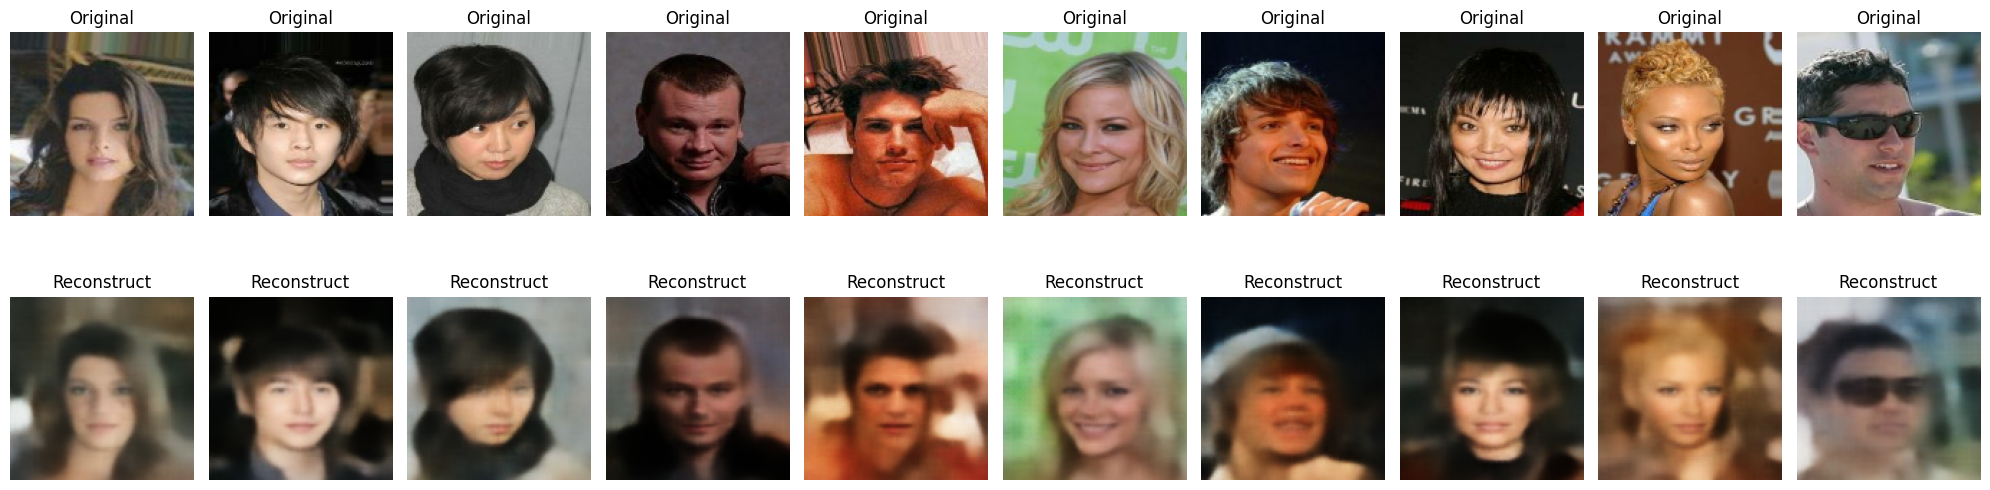

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Extract 10 samples
# .unbatch() ensures we get individual images rather than batch chunks
data_samples = list(test_dataset.unbatch().take(10)) 

fig = plt.figure(figsize=(20, 6))

for i in range(10):
    img = data_samples[i]
    if isinstance(img, tuple): 
        img = img[0] # Take the image if data is (image, label)
    
    # Predict expects a batch, so expand from (128, 128, 3) to (1, 128, 128, 3)
    input_tensor = np.expand_dims(img, axis=0)
    prediction = vae_model.predict(input_tensor, verbose=0)
    
    # Original Image
    plt.subplot(2, 10, i + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")
    
    # Reconstructed Image
    plt.subplot(2, 10, i + 11)
    # np.squeeze removes the batch dimension (1, 128, 128, 3) -> (128, 128, 3)
    plt.imshow(np.squeeze(prediction))
    plt.title("Reconstruct")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Generate new faces using the Variable Autoencoder 

The Variable Autoencoder is capable enough of producing new faces from vectors samped from a standard normal distribution - although the output of the generated faces are not as good quality.

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def vae_generate_images(new_to_show=10):
    # 1. Get the decoder model from your container
    # Assuming 'vae_instance' is your VariableAutoencoder object
    decoder = vae_instance.get_vardecoder()
    
    # 2. Sample random vectors from the standard normal distribution
    # Shape: (number_of_images, latent_dimension)
    random_codes = np.random.normal(size=(new_to_show, 200)).astype("float32")
    
    # 3. Predict/Generate new images
    new_faces = decoder.predict(random_codes, verbose=0)

    # 4. Plotting
    # We calculate rows/cols dynamically to keep the grid clean
    cols = 5
    rows = (new_to_show // cols) + (1 if new_to_show % cols != 0 else 0)
    
    fig = plt.figure(figsize=(15, 3 * rows))

    for i in range(new_to_show):
        ax = fig.add_subplot(rows, cols, i + 1)
        # We use np.clip just in case the sigmoid output has tiny rounding errors
        ax.imshow(np.clip(new_faces[i], 0, 1))
        ax.axis('off')
        ax.set_title(f"Gen {i+1}")
        
    plt.tight_layout()
    plt.show()

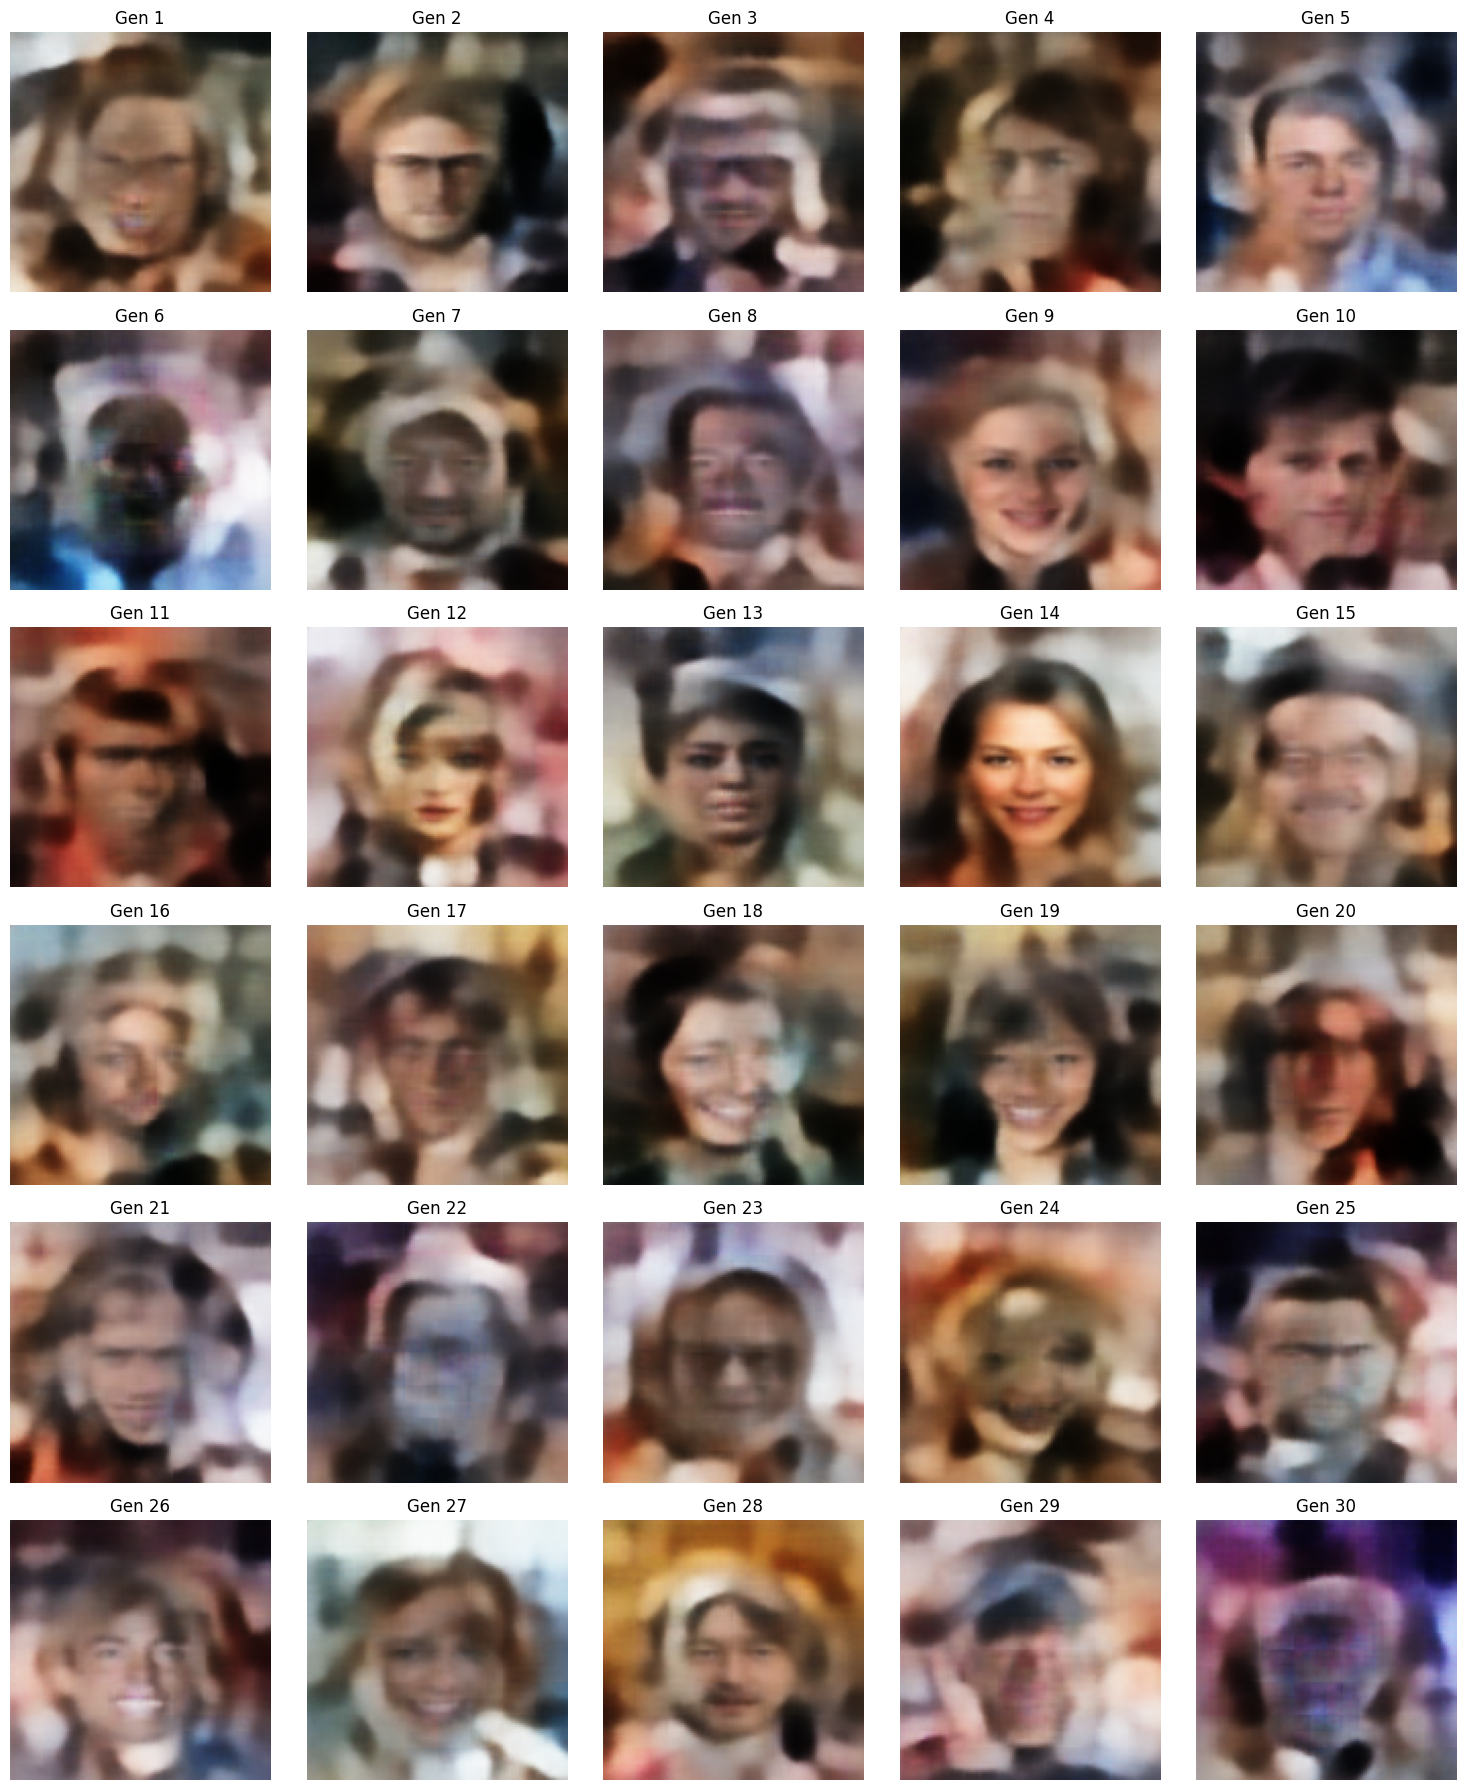

In [38]:
vae_generate_images(30)